# Skin Disease NLP Classification — BioBERT
**Project:** Multimodal Skin Disease Detection  
**Student:** Mohamed Alhusein Abdalla — BUE AI Department  
**Supervisor:** Dr. Gehad Ismail Sayed  
**Dataset:** Symptom2Disease (filtered to 7 skin classes, 350 samples)  
**Platform:** Vast.ai H200  

---
### Classes (7)
Psoriasis, Chicken pox, Impetigo, Fungal infection, Acne, drug reaction, allergy

---
### Experiment: Exp2 — BioBERT Partial Fine-Tuning
- BioBERT backbone: bottom 8 layers frozen, top 4 layers (8-11) trainable
- Classifier head: Dropout(0.3) -> Linear(768, 256) -> ReLU -> Linear(256, 7)
- Loss: CrossEntropyLoss (no label smoothing)
- Optimizer: Adam, LR=2e-5
- Scheduler: CosineAnnealingLR
- Early stopping patience=10, max epochs=50
- Primary metric: Macro F1
- Stratified 70/15/15 split

---
### Evaluation Protocol
- Stratified 70/15/15 split — BEFORE any oversampling
- Primary metric: Macro F1
- Secondary: Accuracy, AUC-ROC
- Early stopping on Macro F1, patience=10

## Step 0 — Configuration

In [22]:
CSV_PATH   = '/root/Symptom2Disease.csv'

SKIN_CLASSES = [
    'Psoriasis',
    'Chicken pox',
    'Impetigo',
    'Fungal infection',
    'Acne',
    'drug reaction',
    'allergy'
]
NUM_CLASSES = len(SKIN_CLASSES)

BIOBERT_MODEL = 'dmis-lab/biobert-base-cased-v1.2'
MAX_LEN       = 128

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

BATCH_SIZE  = 16
NUM_EPOCHS  = 50
LR          = 2e-5
PATIENCE    = 10
SEED        = 42

EXP_NAME    = 'exp2_partial_finetune'
SAVE_DIR    = f'/root/outputs/biobert_exp2_partial_finetune'

import os
os.makedirs(SAVE_DIR, exist_ok=True)
print('Config loaded.')
print(f'Classes ({NUM_CLASSES}): {SKIN_CLASSES}')
print(f'Experiment: {EXP_NAME}')
print(f'Save dir: {SAVE_DIR}')

Config loaded.
Classes (7): ['Psoriasis', 'Chicken pox', 'Impetigo', 'Fungal infection', 'Acne', 'drug reaction', 'allergy']
Experiment: exp2_partial_finetune
Save dir: /root/outputs/biobert_exp2_partial_finetune


## Step 1 — Install Libraries

In [23]:
import sys
!{sys.executable} -m pip install -q transformers datasets scikit-learn torchmetrics matplotlib seaborn pandas tqdm

## Step 2 — Imports

In [24]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel
from torchmetrics.classification import MulticlassF1Score, MulticlassAUROC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA H200
VRAM: 150.1 GB


## Step 3 — Upload & Load Dataset

In [25]:
import zipfile, os

zip_path = '/archive (8).zip'
extract_to = '/root/'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)

print('Extracted files:')
!ls /root/

Extracted files:
Symptom2Disease.csv  dataset  hasbooted  onstart.sh  outputs  ports.log


In [26]:
# Upload Symptom2Disease.csv via JupyterLab file browser to /root/
# then run this cell

df_full = pd.read_csv(CSV_PATH)
print(f'Full dataset shape: {df_full.shape}')

# Filter to skin classes only
df = df_full[df_full['label'].isin(SKIN_CLASSES)].reset_index(drop=True)
df['label_idx'] = df['label'].map({cls: i for i, cls in enumerate(SKIN_CLASSES)})

print(f'Filtered dataset shape: {df.shape}')
print('\nClass distribution:')
print(df['label'].value_counts())
print('\nSample texts:')
for cls in SKIN_CLASSES:
    sample = df[df['label'] == cls]['text'].iloc[0]
    print(f'  [{cls}]: {sample[:100]}...')

Full dataset shape: (1200, 3)
Filtered dataset shape: (350, 4)

Class distribution:
label
Psoriasis           50
Chicken pox         50
Impetigo            50
Fungal infection    50
Acne                50
allergy             50
drug reaction       50
Name: count, dtype: int64

Sample texts:
  [Psoriasis]: I have been experiencing a skin rash on my arms, legs, and torso for the past few weeks. It is red, ...
  [Chicken pox]: I've been experiencing intense itching all over my skin, and it's driving me crazy. I also have a ra...
  [Impetigo]: I have developed a skin rash on my face and neck. The rash is made up of red sores that are blisteri...
  [Fungal infection]: I have raised lumps, a rash that looks red and inflamed, discoloured areas of skin that are differen...
  [Acne]: I've been having a really bad rash on my skin lately. It's full of pus-filled pimples and blackheads...
  [drug reaction]: I have a metallic taste in my mouth, and also have a sense of change of taste and smell. So

## Step 4 — EDA

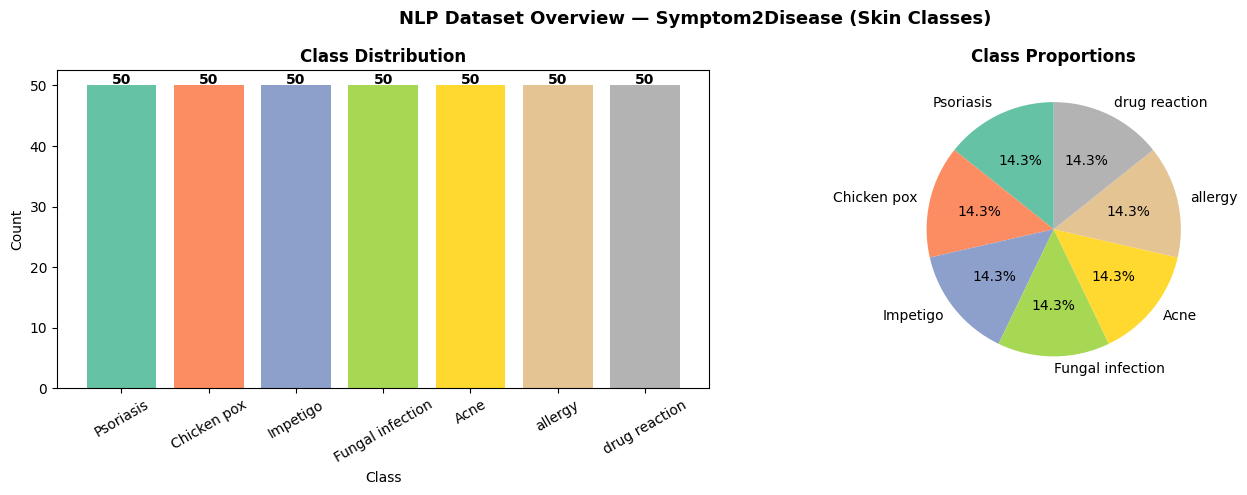

In [27]:
# Class distribution
counts = df['label'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Class Proportions', fontweight='bold')

plt.suptitle('NLP Dataset Overview — Symptom2Disease (Skin Classes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

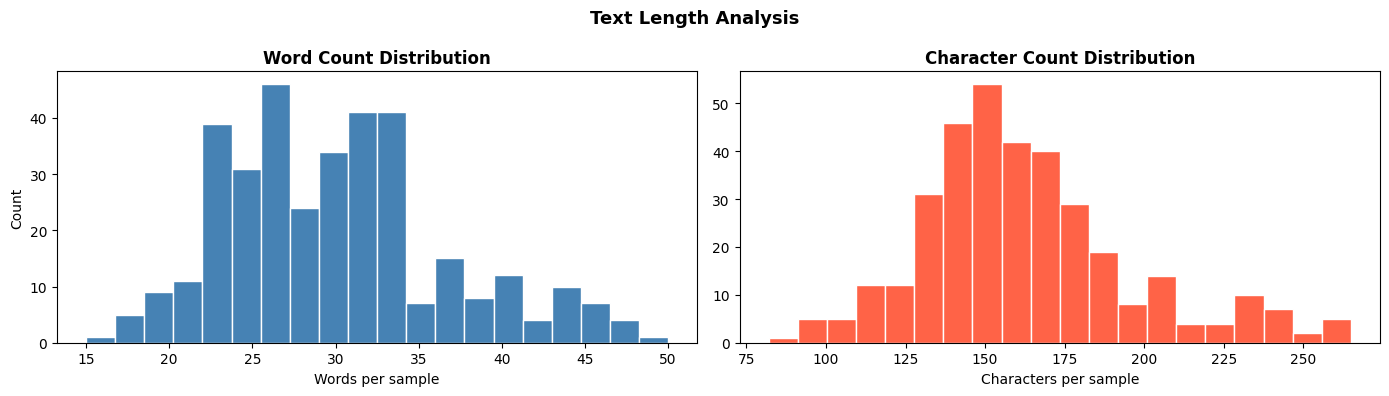

Word count — mean: 29.9, max: 50
Char count — mean: 162.6, max: 265


In [28]:
# Text length distribution
df['word_count'] = df['text'].str.split().str.len()
df['char_count'] = df['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['word_count'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Word Count Distribution', fontweight='bold')
axes[0].set_xlabel('Words per sample')
axes[0].set_ylabel('Count')

axes[1].hist(df['char_count'], bins=20, color='tomato', edgecolor='white')
axes[1].set_title('Character Count Distribution', fontweight='bold')
axes[1].set_xlabel('Characters per sample')

plt.suptitle('Text Length Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/text_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Word count — mean: {df["word_count"].mean():.1f}, max: {df["word_count"].max()}')
print(f'Char count — mean: {df["char_count"].mean():.1f}, max: {df["char_count"].max()}')

## Step 5 — Stratified Split (70 / 15 / 15)

In [29]:
texts  = df['text'].to_numpy()
labels = df['label_idx'].to_numpy()

# Step 1: carve out test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    texts, labels, test_size=TEST_RATIO, stratify=labels, random_state=SEED
)

# Step 2: split train / val
val_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_adjusted, stratify=y_trainval, random_state=SEED
)

print(f'Train : {len(X_train):4d} samples')
print(f'Val   : {len(X_val):4d} samples')
print(f'Test  : {len(X_test):4d} samples')
print(f'Total : {len(X_train)+len(X_val)+len(X_test):4d} samples')

print('\nTrain class counts:')
for i, cls in enumerate(SKIN_CLASSES):
    print(f'  {cls:20s}: {(y_train==i).sum()}')
print('\nTest class counts:')
for i, cls in enumerate(SKIN_CLASSES):
    print(f'  {cls:20s}: {(y_test==i).sum()}')

Train :  244 samples
Val   :   53 samples
Test  :   53 samples
Total :  350 samples

Train class counts:
  Psoriasis           : 35
  Chicken pox         : 35
  Impetigo            : 35
  Fungal infection    : 35
  Acne                : 34
  drug reaction       : 35
  allergy             : 35

Test class counts:
  Psoriasis           : 7
  Chicken pox         : 7
  Impetigo            : 8
  Fungal infection    : 8
  Acne                : 8
  drug reaction       : 7
  allergy             : 8


## Step 6 — Tokenizer & Dataset Class

In [30]:
print(f'Loading tokenizer: {BIOBERT_MODEL}')
tokenizer = AutoTokenizer.from_pretrained(BIOBERT_MODEL)
print('Tokenizer loaded.')

class SkinTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = SkinTextDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = SkinTextDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = SkinTextDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')

Loading tokenizer: dmis-lab/biobert-base-cased-v1.2
Tokenizer loaded.
Train batches: 16
Val batches  : 4
Test batches : 4


## Step 7 — Model (BioBERT + Partial Fine-Tuning)

In [31]:
model = BioBERTClassifier(
    model_name=BIOBERT_MODEL,
    num_classes=NUM_CLASSES,
    freeze_backbone=False
).to(DEVICE)

# Freeze all BERT layers first
for param in model.bert.parameters():
    param.requires_grad = False

# Unfreeze only top 4 transformer layers (layers 8-11)
for i, layer in enumerate(model.bert.encoder.layer):
    if i >= 8:
        for param in layer.parameters():
            param.requires_grad = True

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_p:,}')
print(f'Trainable params : {trainable_p:,}  (top 4 layers + head)')
print(f'Frozen params    : {total_p - trainable_p:,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params     : 108,508,935
Trainable params : 28,550,151  (top 4 layers + head)
Frozen params    : 79,958,784


## Step 8 — Loss, Optimizer, Metrics

In [32]:
criterion = nn.CrossEntropyLoss()  # no label smoothing

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-7
)

f1_metric  = MulticlassF1Score(num_classes=NUM_CLASSES, average='macro').to(DEVICE)
auc_metric = MulticlassAUROC(num_classes=NUM_CLASSES, average='macro').to(DEVICE)

print('Loss      : CrossEntropyLoss (no label smoothing)')
print(f'Optimizer : Adam, LR={LR}')
print('Scheduler : CosineAnnealingLR')
print('Trainable : top 4 BERT layers + classifier head')

Loss      : CrossEntropyLoss (no label smoothing)
Optimizer : Adam, LR=2e-05
Scheduler : CosineAnnealingLR
Trainable : top 4 BERT layers + classifier head


## Step 9 — Train / Eval Functions

In [33]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc='Train', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        out  = model(input_ids, attention_mask)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.append(preds)
        all_labels.append(labels)

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    return total_loss/total, correct/total, f1_metric(all_preds, all_labels).item()


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for batch in tqdm(loader, desc='Eval ', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        out  = model(input_ids, attention_mask)
        loss = criterion(out, labels)

        total_loss += loss.item() * labels.size(0)
        preds = out.argmax(dim=1)
        probs = torch.softmax(out, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.append(preds)
        all_labels.append(labels)
        all_probs.append(probs)

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    all_probs  = torch.cat(all_probs)
    macro_f1   = f1_metric(all_preds, all_labels).item()
    macro_auc  = auc_metric(all_probs, all_labels).item()
    return total_loss/total, correct/total, macro_f1, macro_auc, all_preds, all_labels, all_probs


print('Functions defined.')

Functions defined.


## Step 10 — Training Loop with Early Stopping

In [34]:
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[],
           'train_f1':[], 'val_f1':[], 'val_auc':[]}

best_val_f1     = 0.0
best_epoch      = 0
patience_ctr    = 0
best_model_path = os.path.join(SAVE_DIR, f'biobert_{EXP_NAME}_best.pt')

print(f'Training — max {NUM_EPOCHS} epochs | early stop patience={PATIENCE}')
print(f'Experiment: {EXP_NAME}\n')

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    vl_loss, vl_acc, vl_f1, vl_auc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)
    history['val_auc'].append(vl_auc)

    print(f'Ep {epoch:02d}/{NUM_EPOCHS} | '
          f'Tr Loss={tr_loss:.4f} Acc={tr_acc:.4f} F1={tr_f1:.4f} | '
          f'Vl Loss={vl_loss:.4f} Acc={vl_acc:.4f} F1={vl_f1:.4f} AUC={vl_auc:.4f}',
          end='')

    if vl_f1 > best_val_f1:
        best_val_f1  = vl_f1
        best_epoch   = epoch
        patience_ctr = 0
        torch.save(model.state_dict(), best_model_path)
        print('  ✓ saved')
    else:
        patience_ctr += 1
        print(f'  (patience {patience_ctr}/{PATIENCE})')
        if patience_ctr >= PATIENCE:
            print(f'\nEarly stop at epoch {epoch}.')
            break

print(f'\nBest Val Macro F1: {best_val_f1:.4f} at epoch {best_epoch}')

Training — max 50 epochs | early stop patience=10
Experiment: exp2_partial_finetune



Ep 01/50 | Tr Loss=1.9392 Acc=0.1721 F1=0.1471 | Vl Loss=1.8980 Acc=0.3396 F1=0.2818 AUC=0.8901  ✓ saved


Ep 02/50 | Tr Loss=1.8631 Acc=0.3197 F1=0.2736 | Vl Loss=1.7497 Acc=0.5849 F1=0.5813 AUC=0.9397  ✓ saved


Ep 03/50 | Tr Loss=1.6591 Acc=0.6311 F1=0.6244 | Vl Loss=1.4426 Acc=0.6981 F1=0.7020 AUC=0.9663  ✓ saved


Ep 04/50 | Tr Loss=1.2977 Acc=0.8320 F1=0.8299 | Vl Loss=1.0330 Acc=0.8679 F1=0.8555 AUC=0.9841  ✓ saved


...

Ep 23/50 | Tr Loss=0.0322 Acc=1.0000 F1=1.0000 | Vl Loss=0.0560 Acc=0.9811 F1=0.9821 AUC=1.0000  (patience 6/10)


Ep 24/50 | Tr Loss=0.0305 Acc=1.0000 F1=1.0000 | Vl Loss=0.0520 Acc=0.9811 F1=0.9821 AUC=1.0000  (patience 7/10)


Ep 25/50 | Tr Loss=0.0290 Acc=1.0000 F1=1.0000 | Vl Loss=0.0513 Acc=0.9811 F1=0.9821 AUC=1.0000  (patience 8/10)


Ep 26/50 | Tr Loss=0.0279 Acc=1.0000 F1=1.0000 | Vl Loss=0.0516 Acc=0.9811 F1=0.9821 AUC=1.0000  (patience 9/10)


Ep 27/50 | Tr Loss=0.0269 Acc=1.0000 F1=1.0000 | Vl Loss=0.0513 Acc=0.9811 F1=0.9821 AUC=1.0000  (patience 10/10)

Early stop at epoch 27.

Best Val Macro F1: 0.9821 at epoch 17


## Step 11 — Learning Curves

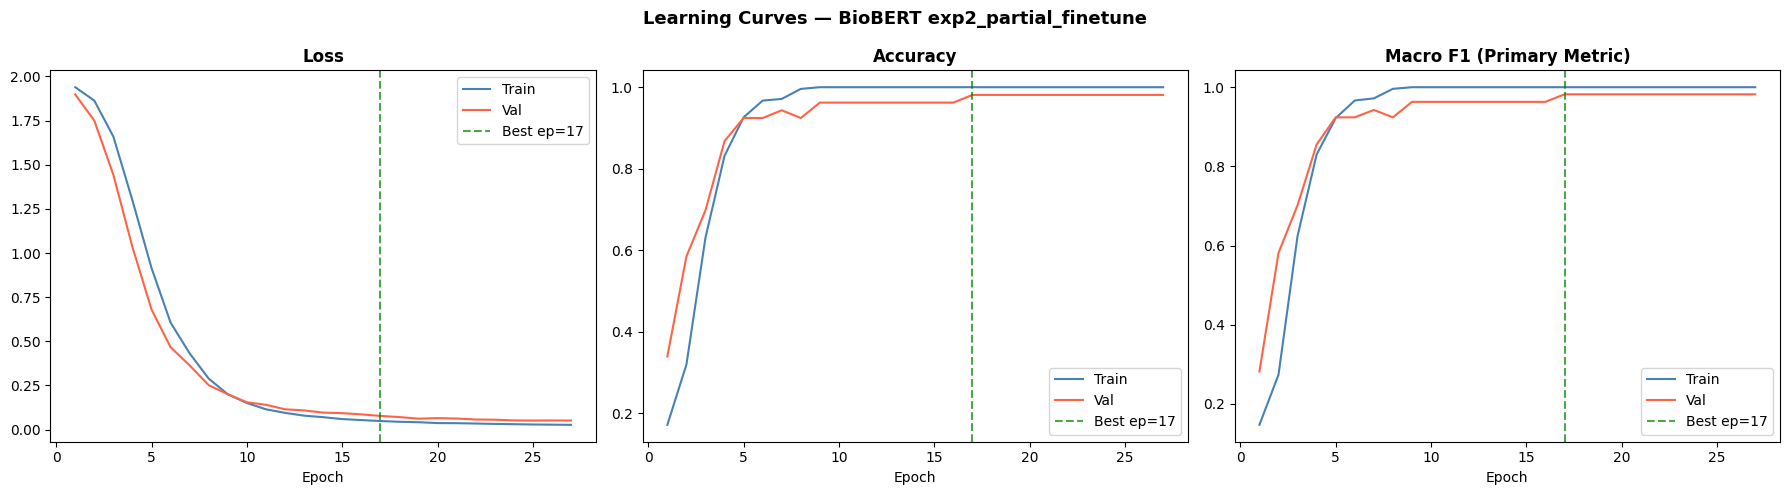

In [35]:
n = len(history['train_loss'])
x = range(1, n + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(
    axes,
    [('train_loss','val_loss'), ('train_acc','val_acc'), ('train_f1','val_f1')],
    ['Loss', 'Accuracy', 'Macro F1 (Primary Metric)']
):
    ax.plot(x, history[metric[0]], label='Train', color='steelblue')
    ax.plot(x, history[metric[1]], label='Val',   color='tomato')
    ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best ep={best_epoch}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()

plt.suptitle(f'Learning Curves — BioBERT {EXP_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12 — Test Set Evaluation (Best Checkpoint)

In [36]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
print(f'Loaded best model from epoch {best_epoch}')

ts_loss, ts_acc, ts_f1, ts_auc, ts_preds, ts_labels, ts_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

print('\n' + '='*50)
print('TEST SET RESULTS')
print('='*50)
print(f'  Accuracy  : {ts_acc*100:.2f}%')
print(f'  Macro F1  : {ts_f1*100:.2f}%   <- PRIMARY METRIC')
print(f'  AUC-ROC   : {ts_auc*100:.2f}%')
print(f'  Loss      : {ts_loss:.4f}')
print('='*50)

Loaded best model from epoch 17



TEST SET RESULTS
  Accuracy  : 96.23%
  Macro F1  : 96.01%   <- PRIMARY METRIC
  AUC-ROC   : 99.65%
  Loss      : 0.1665


## Step 13 — Classification Report (Per-Class)

In [38]:
ts_preds_np  = ts_preds.cpu().numpy()
ts_labels_np = ts_labels.cpu().numpy()

report = classification_report(ts_labels_np, ts_preds_np, target_names=SKIN_CLASSES, digits=4)
print(report)

with open(f'{SAVE_DIR}/classification_report.txt', 'w') as f:
    f.write(f'Model: BioBERT {EXP_NAME}\nBest epoch: {best_epoch}\n')
    f.write(f'Test Accuracy : {ts_acc*100:.2f}%\n')
    f.write(f'Test Macro F1 : {ts_f1*100:.2f}%\n')
    f.write(f'Test AUC-ROC  : {ts_auc*100:.2f}%\n\n')
    f.write(report)
print(f'Saved to {SAVE_DIR}/classification_report.txt')

                  precision    recall  f1-score   support

       Psoriasis     1.0000    0.8571    0.9231         7
     Chicken pox     0.8750    1.0000    0.9333         7
        Impetigo     1.0000    1.0000    1.0000         8
Fungal infection     1.0000    1.0000    1.0000         8
            Acne     1.0000    1.0000    1.0000         8
   drug reaction     1.0000    0.8571    0.9231         7
         allergy     0.8889    1.0000    0.9412         8

        accuracy                         0.9623        53
       macro avg     0.9663    0.9592    0.9601        53
    weighted avg     0.9667    0.9623    0.9620        53

Saved to /root/outputs/biobert_exp2_partial_finetune/classification_report.txt


## Step 14 — Confusion Matrix

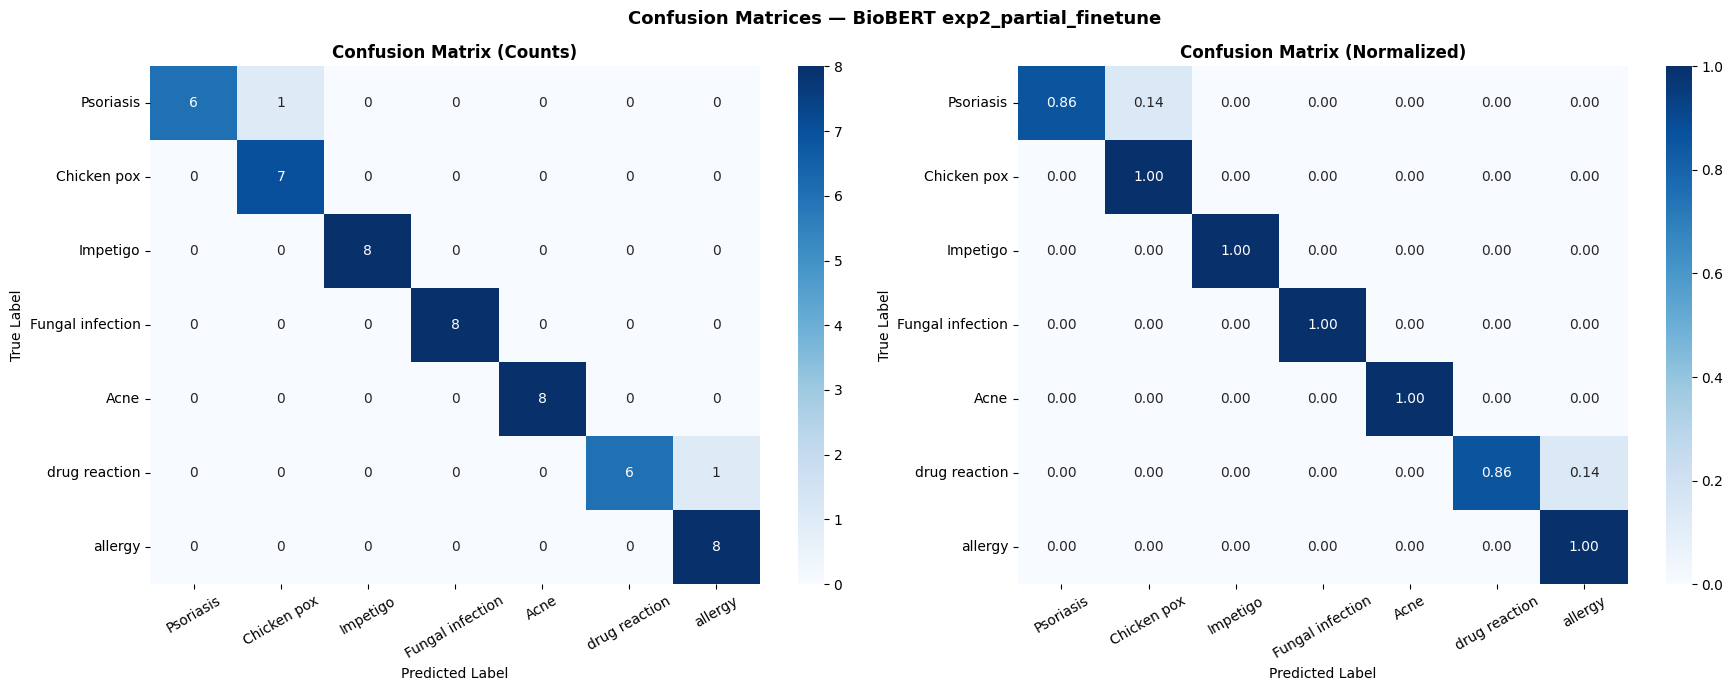

In [39]:
cm      = confusion_matrix(ts_labels_np, ts_preds_np)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Counts', 'Normalized']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=SKIN_CLASSES, yticklabels=SKIN_CLASSES, ax=ax)
    ax.set_title(f'Confusion Matrix ({title})', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(f'Confusion Matrices — BioBERT {EXP_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 15 — ROC Curves

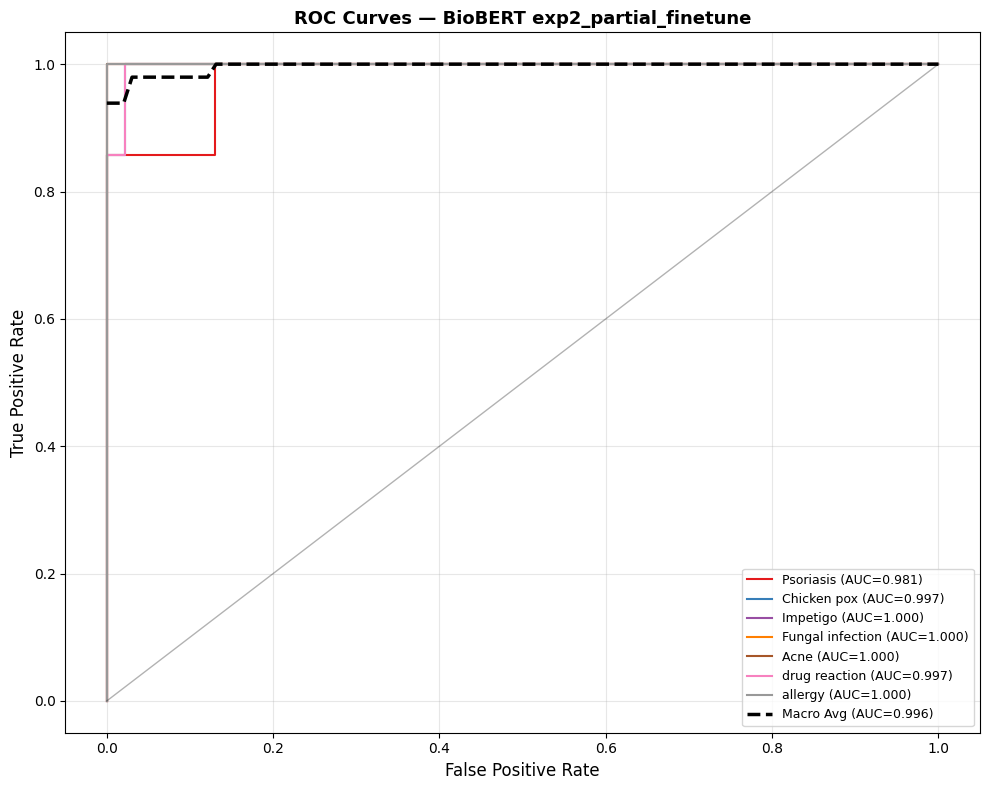

In [40]:
ts_probs_np = ts_probs.cpu().numpy()
y_bin       = label_binarize(ts_labels_np, classes=list(range(NUM_CLASSES)))
colors      = plt.cm.Set1(np.linspace(0, 1, NUM_CLASSES))
mean_fpr    = np.linspace(0, 1, 100)
tprs        = []

fig, ax = plt.subplots(figsize=(10, 8))
for i, (cls, color) in enumerate(zip(SKIN_CLASSES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], ts_probs_np[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{cls} (AUC={roc_auc:.3f})')
    tprs.append(np.interp(mean_fpr, fpr, tpr))

mean_tpr = np.mean(tprs, axis=0)
ax.plot(mean_fpr, mean_tpr, 'k--', lw=2.5,
        label=f'Macro Avg (AUC={auc(mean_fpr, mean_tpr):.3f})')
ax.plot([0,1],[0,1],'k-', lw=1, alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curves — BioBERT {EXP_NAME}', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 16 — Final Summary

In [41]:
print('\n' + '='*60)
print(f'  FINAL RESULTS — BioBERT {EXP_NAME.upper()}')
print('='*60)
print(f'  Dataset       : Symptom2Disease (7 skin classes, 350 samples)')
print(f'  Split         : Stratified 70/15/15')
print(f'  Model         : BioBERT (dmis-lab/biobert-base-cased-v1.2)')
print(f'  Backbone      : Frozen (head only trained)')
print(f'  Best epoch    : {best_epoch}')
print('-'*60)
print(f'  Test Accuracy : {ts_acc*100:.2f}%')
print(f'  Test Macro F1 : {ts_f1*100:.2f}%   <- PRIMARY')
print(f'  Test AUC-ROC  : {ts_auc*100:.2f}%')
print('-'*60)
print(f'  Val Macro F1  : {best_val_f1*100:.2f}%  (checkpoint selection)')
print('='*60)
print(f'\nAll outputs saved to: {SAVE_DIR}')


  FINAL RESULTS — BioBERT EXP2_PARTIAL_FINETUNE
  Dataset       : Symptom2Disease (7 skin classes, 350 samples)
  Split         : Stratified 70/15/15
  Model         : BioBERT (dmis-lab/biobert-base-cased-v1.2)
  Backbone      : Frozen (head only trained)
  Best epoch    : 17
------------------------------------------------------------
  Test Accuracy : 96.23%
  Test Macro F1 : 96.01%   <- PRIMARY
  Test AUC-ROC  : 99.65%
------------------------------------------------------------
  Val Macro F1  : 98.21%  (checkpoint selection)

All outputs saved to: /root/outputs/biobert_exp2_partial_finetune
